### Solución de proyecto de Regresión Lineal: Costos de seguros de vida 

1. Cargar los datos


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split


In [2]:
data=pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv')

2. Analisis descriptivo - EDA 

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.shape

(1338, 7)

In [5]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(1)

In [7]:
columnas_duplicadas = data[data.duplicated()]
columnas_duplicadas

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
data = data.drop_duplicates().reset_index(drop = True)
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


In [11]:
data_numerica = data.select_dtypes(include ='number')
corr_matrix = data_numerica.corr()

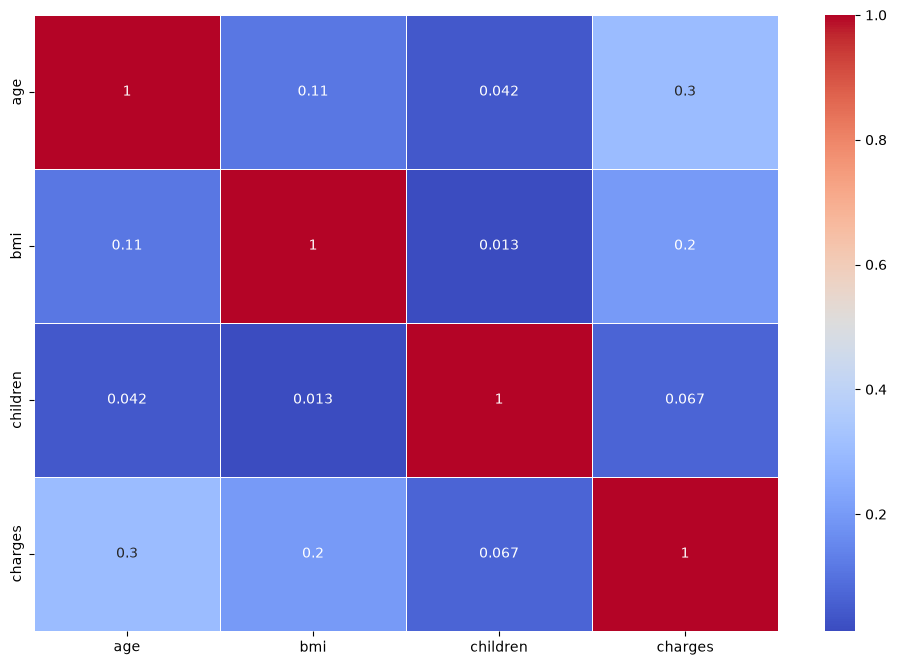

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot = True,
    cmap='coolwarm',
    linewidths =0.5,
    cbar=True,
)

plt.show()

Distribucion de la varible objetivo

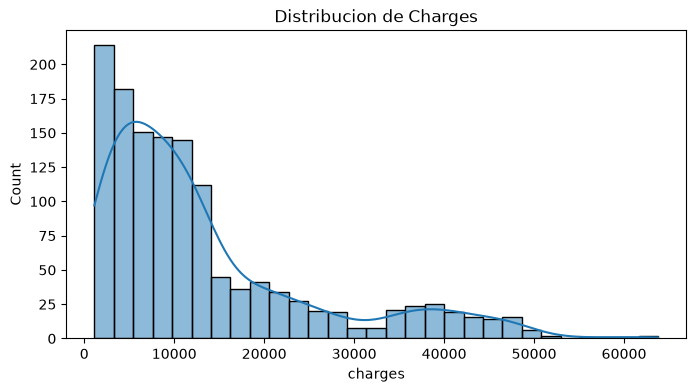

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(data['charges'], kde = True)
plt.title('Distribucion de Charges')

plt.show()

Distribución de las variables categóricas

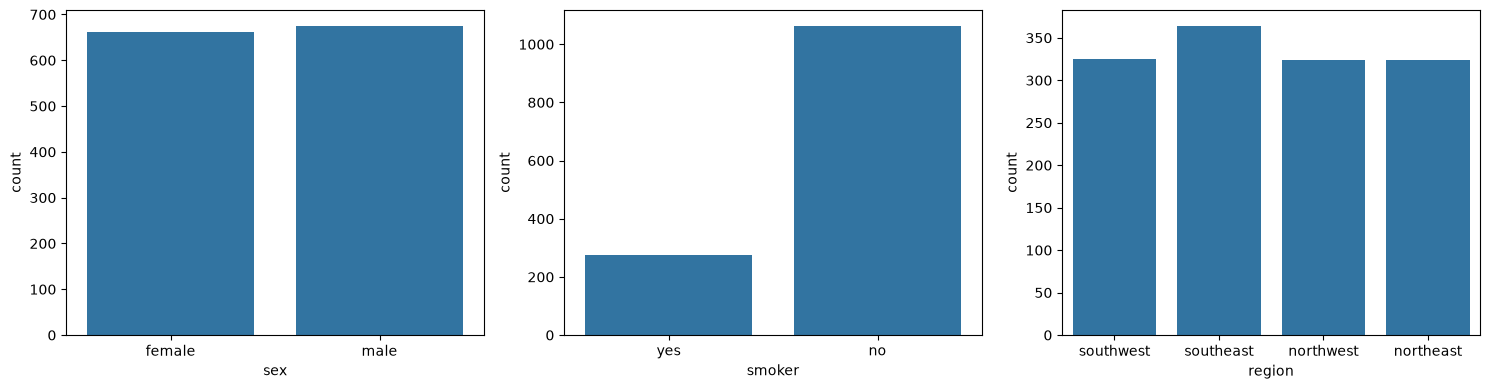

In [14]:
cols_cat = ['sex', 'smoker', 'region']
fig, axes = plt.subplots (1, 3, figsize=(15,4))

for i, col in enumerate (cols_cat):
    sns.countplot(x=col, data=data, ax=axes[i])

plt.tight_layout()
plt.show()

Relación de charges con las variables categoricas

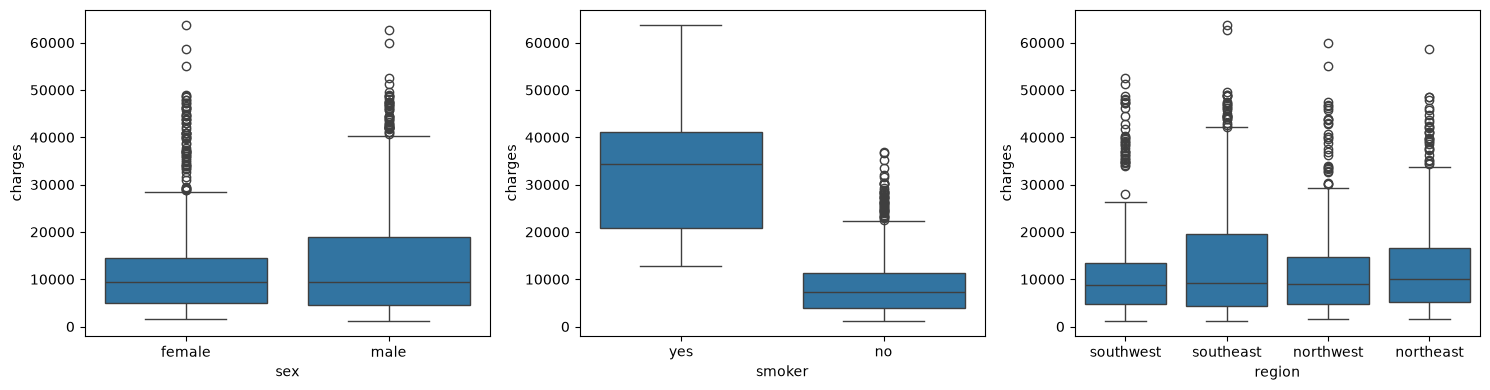

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for i, col in enumerate(cols_cat):
    sns.boxplot(x=col, y='charges', data=data, ax=axes[i])

plt.tight_layout()
plt.show()

A partir de los graficos de relacion entre charges y las variables categoricas, se puede evidenciar que, las personas que son smoker tienen un charge más alto a diferencia de los que no lo son. 


Relacion de charges con variables numericas

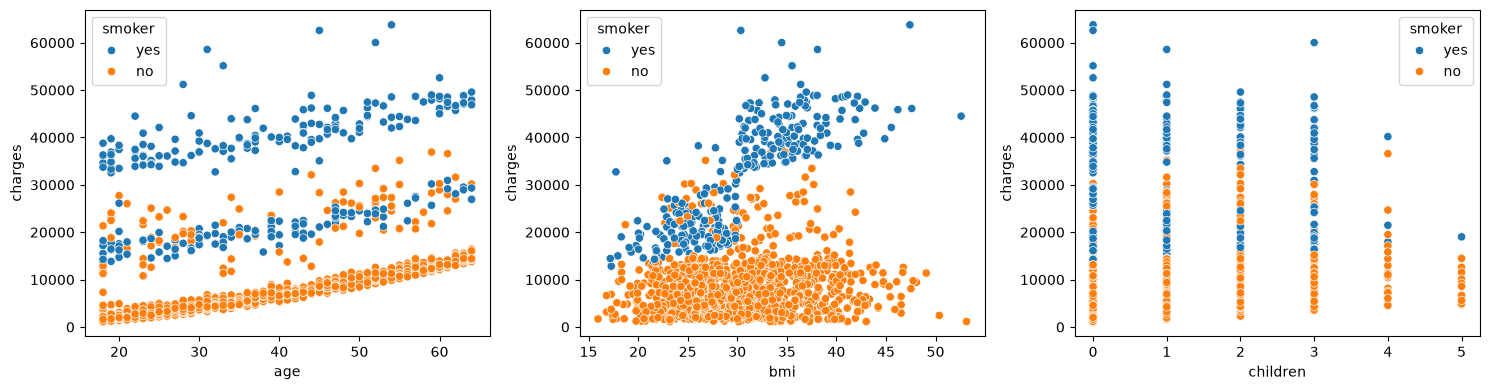

In [16]:
num_cols = ["age", "bmi", "children"]
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(num_cols):
    sns.scatterplot(x=col, y="charges", hue="smoker", data=data, ax=axes[i])
plt.tight_layout()
plt.show()

- Se identifica que al tener una mayoria de edad y ser smoker tiende a tener un charge mayor, este muestra un comportamiento lineal

- BMI = Se evidencia que al ser smoker y tener un BMI entre 30-35 se tiene un charge mas alto, asi mismo a medida que aumenta el BMI el charge tambien lo hace, 

- Children = No tiene ninguna relacion lineal con charge, pero si se puede ver que a menor edad, puede tener un mayor charge.

3. Construcción de modelo Regresión Lineal

- Procesamiento de datos (Codificamiento de variables categoricas)

In [17]:
from sklearn.preprocessing import LabelEncoder

data_encoded = data.copy()
le = LabelEncoder()
data_encoded['sex'] = le.fit_transform(data_encoded['sex'])
data_encoded['smoker'] = le.fit_transform(data_encoded['smoker'])

data_encoded = pd.get_dummies (data_encoded, columns =['region'], drop_first=True)

data_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


Matriz de correlacion

In [18]:
corr_matriz = data_encoded.corr()
corr_matriz

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
age,1.000000,-0.019814,0.109344,0.041536,-0.025587,0.298308,0.001495,-0.012311,0.009415
sex,-0.019814,1.000000,0.046397,0.017848,0.076596,0.058044,-0.012482,0.017578,-0.003767
bmi,0.109344,0.046397,1.000000,0.012755,0.003746,0.198401,-0.136138,0.270057,-0.006211
children,0.041536,0.017848,0.012755,1.000000,0.007331,0.067389,0.026044,-0.023492,0.021538
smoker,-0.025587,0.076596,0.003746,0.007331,1.000000,0.787234,-0.036321,0.068282,-0.037168
charges,0.298308,0.058044,0.198401,0.067389,0.787234,1.000000,-0.038695,0.073578,-0.043637
region_northwest,0.001495,-0.012482,-0.136138,0.026044,-0.036321,-0.038695,1.000000,-0.345909,-0.320493
region_southeast,-0.012311,0.017578,0.270057,-0.023492,0.068282,0.073578,-0.345909,1.000000,-0.346614
region_southwest,0.009415,-0.003767,-0.006211,0.021538,-0.037168,-0.043637,-0.320493,-0.346614,1.000000


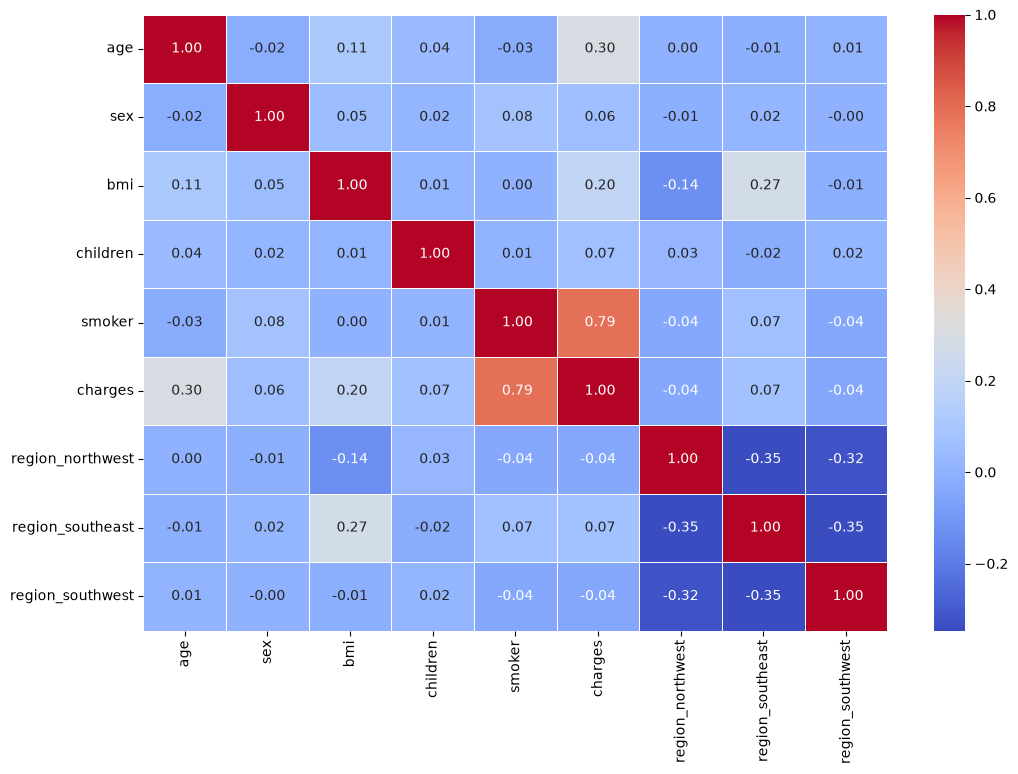

In [19]:
plt.figure ( figsize=(12,8))

sns.heatmap(
    corr_matriz,
    annot = True,
    fmt=' .2f',
    cmap='coolwarm',
    linewidths =0.5,
    cbar=True,
)

plt.show()

Se puede evidenciar que las variables que tienen un correlacion positiva con el charges son age, bmi y smoker, es decir, ser fumador y tener una mayoria de edad, hace incrementar el charge del seguro.

- Separación del Train y Test

In [20]:

X = data_encoded.drop('charges', axis = 1)
y = data_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state=42)

print ('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (1069, 8) Test: (268, 8)


Escalamiento de las variables continuas (age, BMI)

In [24]:
data.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [25]:
cols_scaler = ["age", "bmi"]

scaler = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_scaler] = scaler.fit_transform(X_train[cols_scaler])
X_test_scaled[cols_scaler] = scaler.transform(X_test[cols_scaler]) 

#Convirtiendo las dummies de region a enteros 
region_cols = ["region_northwest", "region_southeast", "region_southwest"]
X_train_scaled[region_cols] = X_train_scaled[region_cols].astype(int)
X_test_scaled[region_cols] = X_test_scaled[region_cols].astype(int)

X_train_scaled.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
1113,0.108696,1,0.230024,0,0,0,0,0
967,0.065217,1,0.263250,2,0,0,0,0
598,0.739130,0,0.580172,2,0,1,0,0
170,0.978261,1,0.686306,0,0,0,1,0
275,0.630435,0,0.286252,2,0,0,0,0


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)

In [32]:
print(f'Intercepto (a):{modelo.intercept_}')
print(f'Coeficientes (b1,b2): {modelo.coef_}')
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Intercepto (a):-1538.3843343017961
Coeficientes (b1,b2): [11417.69313034  -101.54205399 11846.1325602    533.0099888
 23077.76459287  -391.76145478  -838.91961573  -659.13975155]
R2: 0.8069287081198014
MAE: 4177.045561036321


Se obtiene un R2 = 0,80, indica que tiene una regresión lineal positiva. En este caso no sería necesario hacer una optimización del modelo, es mejor usar otro modelo para saber como se comporta y poder optimizarlo ya que este no tiene hiperparametros para optimizar

4. Optimización del modelo

In [ ]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=2.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge -> R2:", r2_score(y_test, y_pred_ridge), 
        "MAE:", mean_absolute_error(y_test, y_pred_ridge))

# Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso -> R2:", r2_score(y_test, y_pred_lasso), 
      "MAE:", mean_absolute_error(y_test, y_pred_lasso))

Ridge -> R2: 0.8034319645628594 MAE: 4192.635245270543
Lasso -> R2: 0.8067924418406215 MAE: 4176.9085019754175


Se puede evidenciar que al realizar una pequeña optimización del modelo, se sigue obteniendo el mismo valor del R2 